### Fine-tuning head diagram

BERT-large task head: the final encoder layer's output (6 x 1024), take the
[CLS] vector, dropout, pooler dense + tanh, dropout, then map to 3 logits
(dovish / hawkish / neutral).

Writes `finetuning_diagram.png`.

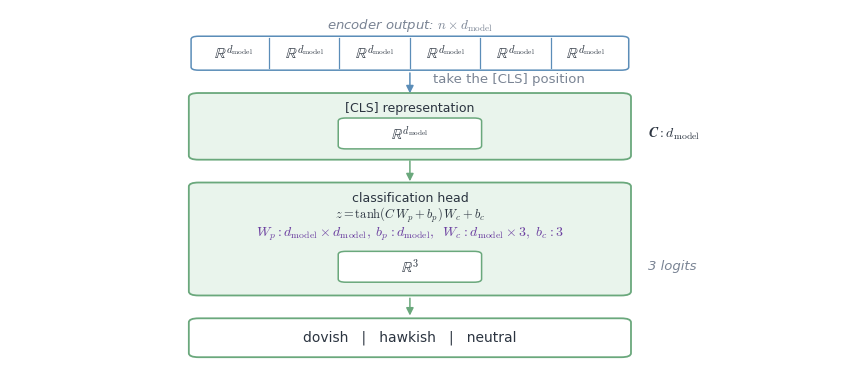

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK = "#2b3440"
SAND_E = "#c9a96a"
BLUE_E = "#5b8db8"
GREEN, GREEN_E = "#e9f4ec", "#6aa87c"
GREYT = "#7a8494"
TRAIN = "#6b3fa0"

fig, ax = plt.subplots(figsize=(8.6, 3.88))
ax.set_xlim(0, 11.0)
ax.set_ylim(-4.0, 7.6)
ax.axis("off")

X, W = 2.5, 5.6
MID = X + W / 2
NX = X + W + 0.35  # left edge of the side-note column, hugging the boxes

MATHR = r"$\mathbb{R}^{d_{\mathrm{model}}}$"
MATH3 = r"$\mathbb{R}^{3}$"
CLBL = r"$\boldsymbol{C}: d_{\mathrm{model}}$"
HEADL = r"$z = \mathrm{Dropout}\left(\tanh(\mathrm{Dropout}(C)\,W_p + b_p)\right)\,W_c + b_c$"
HEADTBL = (
    r"$W_p: d_{\mathrm{model}} \times d_{\mathrm{model}},\; b_p: d_{\mathrm{model}},"
    r"\;\; W_c: d_{\mathrm{model}} \times 3,\; b_c: 3$"
)


def box(x, y, w, h, text, fc, ec, fs=9, lw=1.3):
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.13",
            facecolor=fc,
            edgecolor=ec,
            linewidth=lw,
        )
    )
    if text:
        ax.text(
            x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=INK
        )


def dim(x, y, text, ha="left"):
    ax.text(x, y, text, ha=ha, va="center", fontsize=9.5, style="italic", color=GREYT)


def note(y, text, fs=9.5):
    ax.text(MID + 0.3, y, text, fontsize=fs, color=GREYT, ha="left")


def arrow(y0, c=INK, x=None, dy=0.84):
    if x is None:
        x = MID
    ax.add_patch(
        FancyArrowPatch(
            (x, y0), (x, y0 - dy), arrowstyle="-|>", mutation_scale=11, color=c, lw=1.1
        )
    )


def table_row(y, labels, fs=8.2, fc="white", ec=SAND_E, h=0.9, x=None, w=None):
    if x is None:
        x = X
    if w is None:
        w = W
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.10",
            facecolor=fc,
            edgecolor=ec,
            linewidth=1.1,
        )
    )
    n = len(labels)
    for i, t in enumerate(labels):
        if i:
            ax.plot(
                [x + i * w / n, x + i * w / n],
                [y - 0.03, y + h + 0.03],
                color=ec,
                lw=0.9,
            )
        ax.text(
            x + (i + 0.5) * w / n,
            y + h / 2,
            t,
            ha="center",
            va="center",
            fontsize=fs,
            family="DejaVu Sans Mono",
            color=INK,
        )


# green step block: title, optional equation and parameter line, shape row inside
def block(y, title, eq, cells, cw, sub=None):
    h = 3.4 if sub else 1.9
    ry = y + (0.40 if sub else 0.32)
    box(X, y, W, h, "", GREEN, GREEN_E)
    if sub:
        ax.text(MID, y + 3.00, title, ha="center", va="center", fontsize=9, color=INK)
        ax.text(MID, y + 2.45, eq, ha="center", va="center", fontsize=9, color=INK)
        ax.text(
            MID, y + 1.85, sub, ha="center", va="center", fontsize=10.0, color=TRAIN
        )
    else:
        ax.text(MID, y + 1.52, title, ha="center", va="center", fontsize=9, color=INK)
    table_row(ry, cells, fs=10.5, ec=GREEN_E, h=0.8, x=MID - cw / 2, w=cw)
    return ry + 0.4  # centre height of the shape row, for side labels


# the final encoder layer's output, as it leaves the encoder figure
table_row(5.75, [MATHR] * 6, fs=11.0, ec=BLUE_E)
dim(MID, 7.10, r"encoder output: $n \times d_{\mathrm{model}}$", ha="center")
arrow(5.65, BLUE_E)
note(5.25, "take the [CLS] position")

ry = block(2.88, "[CLS] representation", None, [MATHR], 1.7)
ax.text(NX, ry, CLBL, ha="left", va="center", fontsize=10, color=INK)
arrow(2.80, GREEN_E)

ry = block(-1.52, "classification head", HEADL, [MATH3], 1.7, sub=HEADTBL)
dim(NX, ry, "3 logits")
arrow(-1.65, GREEN_E, dy=0.74)

box(X, -3.52, W, 1.0, "dovish   |   hawkish   |   neutral", "white", GREEN_E, fs=10)

fig.tight_layout()
fig.savefig("finetuning_diagram.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("finetuning_diagram.pdf", bbox_inches="tight", facecolor="white")